In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/README.md
/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv


In [2]:
# ============================================
# CELL 1 - IMPORT LIBRARIES
# ============================================

import os
import time
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ============================================
# LOAD DATASET
# ============================================

import pandas as pd

DATA_PATH = "/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (15420, 29)


In [4]:
# ============================================
# CELL 3 - CHECK DATASET COLUMNS
# ============================================

print("Columns in the dataset:\n")

for i, column in enumerate(df.columns):
    print(i, ":", column)

Columns in the dataset:

0 : athlete_id
1 : heart_rate
2 : body_temperature
3 : hydration_level
4 : sleep_quality
5 : recovery_score
6 : stress_level
7 : muscle_activity
8 : joint_angles
9 : gait_speed
10 : cadence
11 : step_count
12 : jump_height
13 : ground_reaction_force
14 : range_of_motion
15 : ambient_temperature
16 : humidity
17 : altitude
18 : playing_surface
19 : training_intensity
20 : training_duration
21 : training_load
22 : fatigue_index
23 : injury_occurred
24 : session_id
25 : sport_type
26 : gender
27 : age
28 : bmi


In [5]:
# ============================================
# CELL 4 - SELECT MODEL FEATURES
# ============================================

# ONLY these 7 factors are used by XGBoost
FEATURES = [
    "training_duration",
    "training_intensity",
    "training_load",
    "heart_rate",
    "sleep_quality",
    "recovery_score",
    "stress_level"
]

# These are identifiers ONLY
IDENTIFIERS = [
    "athlete_id",
    "session_id"
]

# Prediction target
TARGET = "fatigue_index"


print("MODEL INPUT FEATURES:")

for feature in FEATURES:
    print(" -", feature)


print("\nIDENTIFIERS (NOT USED FOR TRAINING):")

for identifier in IDENTIFIERS:
    print(" -", identifier)


print("\nTARGET:")

print(" -", TARGET)

MODEL INPUT FEATURES:
 - training_duration
 - training_intensity
 - training_load
 - heart_rate
 - sleep_quality
 - recovery_score
 - stress_level

IDENTIFIERS (NOT USED FOR TRAINING):
 - athlete_id
 - session_id

TARGET:
 - fatigue_index


In [6]:
# ============================================
# CELL 5 - VERIFY REQUIRED COLUMNS
# ============================================

required_columns = FEATURES + IDENTIFIERS + [TARGET]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if len(missing_columns) == 0:
    print("All required columns are present!")

else:
    print("Missing columns:")

    for column in missing_columns:
        print(" -", column)

All required columns are present!


In [7]:
# ============================================
# CELL 6 - CREATE MODEL DATASET
# ============================================

# Only model features + target
model_df = df[FEATURES + [TARGET]].copy()

print("Model dataset shape:", model_df.shape)

display(model_df.head())

Model dataset shape: (15420, 8)


,training_duration,training_intensity,training_load,heart_rate,sleep_quality,recovery_score,stress_level,fatigue_index
0,79.106564,5.678475,548.417962,NaN,5.466370,77.899691,0.375825,45.028687
1,116.954654,NaN,538.043815,40.000000,6.899090,74.845323,0.279165,42.254717
2,96.354742,6.643242,647.784339,76.174609,9.574152,83.538316,0.334061,61.870056
3,97.619130,6.194427,336.553431,100.543724,7.614297,79.966618,0.218766,50.268845
4,83.155527,5.835804,496.076352,78.001235,5.631979,56.945979,0.484086,29.233575


In [8]:
# ============================================
# CELL 7 - CONVERT SELECTED COLUMNS TO NUMERIC
# ============================================

for column in FEATURES + [TARGET]:
    model_df[column] = pd.to_numeric(
        model_df[column],
        errors="coerce"
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [9]:
# ============================================
# CELL 8 - CHECK MISSING VALUES
# ============================================

print("Missing values:\n")

print(model_df.isnull().sum())

Missing values:

training_duration       0
training_intensity    632
training_load           0
heart_rate            354
sleep_quality         493
recovery_score          0
stress_level            0
fatigue_index           0
dtype: int64


In [10]:
# ============================================
# CELL 9 - REMOVE MISSING TARGET ROWS
# ============================================

before = len(model_df)

model_df = model_df.dropna(
    subset=[TARGET]
)

after = len(model_df)

print("Rows before:", before)
print("Rows after :", after)
print("Rows removed:", before - after)

Rows before: 15420
Rows after : 15420
Rows removed: 0


In [11]:
# ============================================
# CELL 10 - SEPARATE X AND TARGET
# ============================================

X = model_df[FEATURES].copy()

fatigue_index = model_df[TARGET].copy()

print("Input shape :", X.shape)
print("Target shape:", fatigue_index.shape)

Input shape : (15420, 7)
Target shape: (15420,)


In [12]:
# ============================================
# CELL 11 - TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train_fatigue, y_test_fatigue = train_test_split(
    X,
    fatigue_index,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 12336
Testing samples : 3084


In [13]:
# ============================================
# CELL 12 - FATIGUE CLASS BOUNDARIES
# ============================================

q1 = y_train_fatigue.quantile(1/3)
q2 = y_train_fatigue.quantile(2/3)

print("Low / Moderate boundary :", q1)
print("Moderate / High boundary:", q2)

Low / Moderate boundary : 47.26018698422907
Moderate / High boundary: 68.8946614564474


In [14]:
# ============================================
# CELL 13 - CREATE FATIGUE CLASSES
# ============================================

def fatigue_to_class(value):
    
    if value <= q1:
        return 0
    
    elif value <= q2:
        return 1
    
    else:
        return 2


y_train = y_train_fatigue.apply(
    fatigue_to_class
)

y_test = y_test_fatigue.apply(
    fatigue_to_class
)

class_names = [
    "Low",
    "Moderate",
    "High"
]

print("Class mapping:")
print("0 =", class_names[0])
print("1 =", class_names[1])
print("2 =", class_names[2])

Class mapping:
0 = Low
1 = Moderate
2 = High


In [15]:
# ============================================
# CELL 14 - CLASS DISTRIBUTION
# ============================================

print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
fatigue_index
0    4112
1    4112
2    4112
Name: count, dtype: int64

Testing class distribution:
fatigue_index
0    1074
1    1053
2     957
Name: count, dtype: int64


In [16]:
# ============================================
# CELL 15 - HANDLE MISSING INPUT VALUES
# ============================================

train_medians = X_train.median()

X_train = X_train.fillna(
    train_medians
)

X_test = X_test.fillna(
    train_medians
)

print("Missing values in training:", X_train.isnull().sum().sum())
print("Missing values in testing :", X_test.isnull().sum().sum())

Missing values in training: 0
Missing values in testing : 0


In [17]:
# ============================================
# CELL 16 - IMPORT XGBOOST
# ============================================

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [18]:
# ============================================
# CELL 17 - XGBOOST CONFIGURATION
# ============================================

EPOCHS = 50

BATCH_SIZE = 32

xgb_model = xgb.XGBClassifier(
    n_estimators=EPOCHS,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("XGBoost configured!")
print("Epochs / boosting rounds:", EPOCHS)
print("Batch size display:", BATCH_SIZE)
print("Number of classes:", 3)
print("Classes:", class_names)

XGBoost configured!
Epochs / boosting rounds: 50
Batch size display: 32
Number of classes: 3
Classes: ['Low', 'Moderate', 'High']


In [19]:
# ============================================
# CELL 18 - XGBOOST TRAINING
# ============================================

from sklearn.metrics import log_loss, accuracy_score

training_start = time.perf_counter()

print("Starting training...")
print("Epochs:", EPOCHS)
print("Training samples:", len(X_train))
print("Batch size:", BATCH_SIZE)
print("Model: XGBoost")
print("=" * 65)

history = []

# Train the model
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=False
)

# Get XGBoost evaluation history
results = xgb_model.evals_result()

train_losses = results["validation_0"]["mlogloss"]
test_losses = results["validation_1"]["mlogloss"]

total_batches = int(
    np.ceil(len(X_train) / BATCH_SIZE)
)

# Print all 50 epochs
for epoch in range(1, EPOCHS + 1):

    train_loss = train_losses[epoch - 1]
    test_loss = test_losses[epoch - 1]

    # Predictions using trees up to this stage
    train_prob = xgb_model.predict_proba(
        X_train,
        iteration_range=(0, epoch)
    )

    train_pred = np.argmax(
        train_prob,
        axis=1
    )

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": test_loss,
        "training_accuracy": train_accuracy
    })

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Batch [{total_batches}/{total_batches}] "
        f"Loss: {train_loss:.4f}"
    )

    print("-" * 65)
    print(f"Epoch {epoch} completed")
    print(f"Average loss: {train_loss:.4f}")
    print(f"Validation loss: {test_loss:.4f}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print("-" * 65)

total_training_time = (
    time.perf_counter() - training_start
)

print("\nTraining completed!")
print(
    f"Total training time: "
    f"{total_training_time:.2f} seconds"
)

print(
    f"Total training time: "
    f"{total_training_time / 60:.2f} minutes"
)

Starting training...
Epochs: 50
Training samples: 12336
Batch size: 32
Model: XGBoost
Epoch [1/50] Batch [386/386] Loss: 1.0713
-----------------------------------------------------------------
Epoch 1 completed
Average loss: 1.0713
Validation loss: 1.0730
Training accuracy: 0.6808
-----------------------------------------------------------------
Epoch [2/50] Batch [386/386] Loss: 1.0456
-----------------------------------------------------------------
Epoch 2 completed
Average loss: 1.0456
Validation loss: 1.0493
Training accuracy: 0.6874
-----------------------------------------------------------------
Epoch [3/50] Batch [386/386] Loss: 1.0299
-----------------------------------------------------------------
Epoch 3 completed
Average loss: 1.0299
Validation loss: 1.0350
Training accuracy: 0.6856
-----------------------------------------------------------------
Epoch [4/50] Batch [386/386] Loss: 1.0079
-----------------------------------------------------------------
Epoch 4 completed

In [20]:
# ============================================
# CELL 19 - SAVE TRAINING HISTORY
# ============================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    "/kaggle/working/xgboost_training_history.csv",
    index=False
)

print("Training history saved!")

display(history_df.head())

Training history saved!


,epoch,train_loss,validation_loss,training_accuracy
0,1,1.071290,1.073038,0.680772
1,2,1.045637,1.049281,0.687419
2,3,1.029865,1.035007,0.685636
3,4,1.007932,1.014725,0.689689
4,5,0.987319,0.995879,0.689608


In [21]:
# ============================================
# CELL 20 - FINAL TEST PREDICTION
# ============================================

y_pred = xgb_model.predict(
    X_test
)

y_prob = xgb_model.predict_proba(
    X_test
)

print("Test prediction completed!")
print("Test samples:", len(y_test))

Test prediction completed!
Test samples: 3084


In [22]:
# ============================================
# CELL 21 - EVALUATION METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

try:
    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    roc_auc = np.nan


print("=" * 55)
print("          XGBOOST EVALUATION METRICS")
print("=" * 55)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC-AUC         : {roc_auc:.4f}")

print("=" * 55)

          XGBOOST EVALUATION METRICS
Accuracy        : 0.6566
Precision       : 0.6611
Recall          : 0.6585
F1 Score        : 0.6597
ROC-AUC         : 0.8412


In [23]:
# ============================================
# CELL 22 - CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print("=" * 65)
print("              XGBOOST CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

              XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.72      0.71      0.72      1074
    Moderate       0.52      0.53      0.52      1053
        High       0.75      0.73      0.74       957

    accuracy                           0.66      3084
   macro avg       0.66      0.66      0.66      3084
weighted avg       0.66      0.66      0.66      3084



Confusion Matrix:
[[765 289  20]
 [274 561 218]
 [ 23 235 699]]


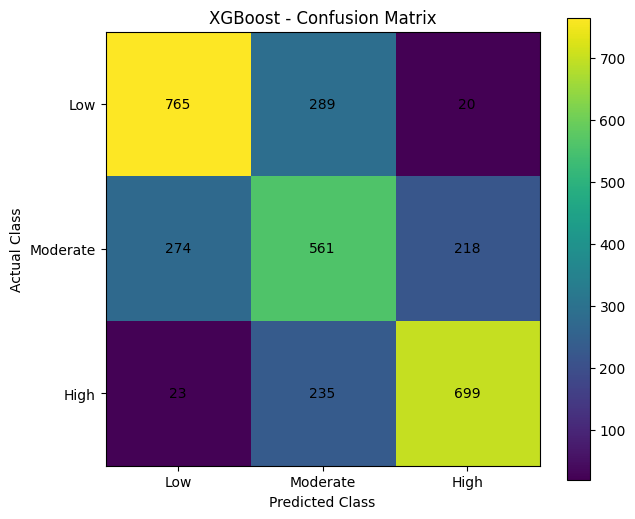

In [24]:
# ============================================
# CELL 23 - CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(3),
    class_names
)

plt.yticks(
    range(3),
    class_names
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [25]:
# ============================================
# CELL 24 - SAVE EVALUATION METRICS CSV
# ============================================

evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_df.to_csv(
    "/kaggle/working/xgboost_evaluation_metrics.csv",
    index=False
)

print("Evaluation metrics CSV saved!")

display(evaluation_df)

Evaluation metrics CSV saved!


,Metric,Score
0,Accuracy,0.656615
1,Precision,0.661129
2,Recall,0.658487
3,F1 Score,0.659734
4,ROC-AUC,0.841163


In [26]:
# ============================================
# CELL 25 - WALL TIME CSV
# ============================================

wall_time_df = pd.DataFrame({
    "Model": ["XGBoost"],
    "Epochs": [EPOCHS],
    "Training_Samples": [len(X_train)],
    "Testing_Samples": [len(X_test)],
    "Batch_Size_Display": [BATCH_SIZE],
    "Wall_Time_Seconds": [total_training_time],
    "Wall_Time_Minutes": [
        total_training_time / 60
    ]
})

wall_time_df.to_csv(
    "/kaggle/working/xgboost_wall_time.csv",
    index=False
)

print("Wall time CSV saved!")

display(wall_time_df)

Wall time CSV saved!


,Model,Epochs,Training_Samples,Testing_Samples,Batch_Size_Display,Wall_Time_Seconds,Wall_Time_Minutes
0,XGBoost,50,12336,3084,32,1.121788,0.018696


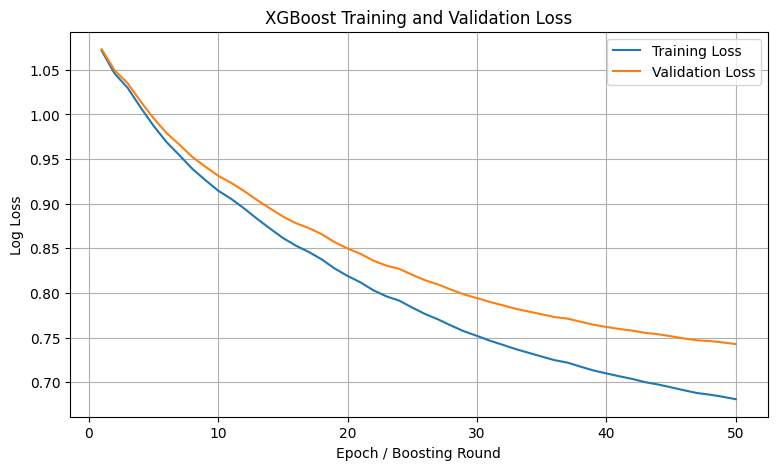

In [27]:
# ============================================
# CELL 26 - TRAINING / VALIDATION LOSS
# ============================================

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch / Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

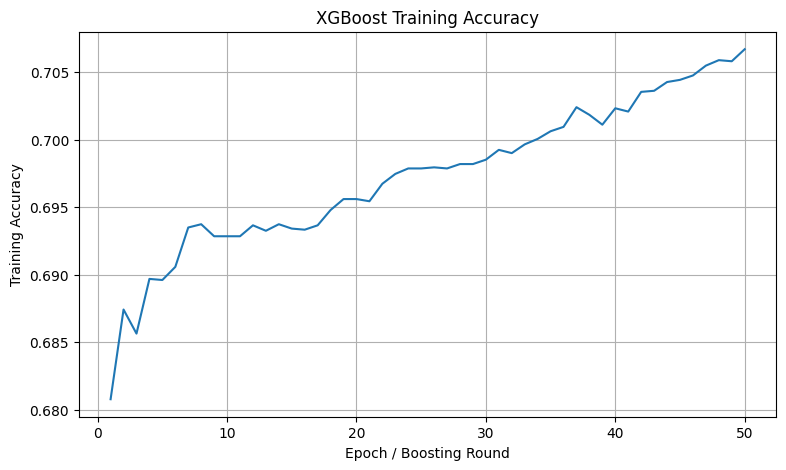

In [28]:
# ============================================
# CELL 27 - TRAINING ACCURACY
# ============================================

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["training_accuracy"]
)

plt.xlabel("Epoch / Boosting Round")
plt.ylabel("Training Accuracy")
plt.title("XGBoost Training Accuracy")

plt.grid(True)

plt.show()

In [29]:
# ============================================
# CELL 28 - XGBOOST FEATURE IMPORTANCE
# ============================================

importance_values = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importance_values
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
2,training_load,0.562151
1,training_intensity,0.195134
5,recovery_score,0.079634
0,training_duration,0.056454
6,stress_level,0.041451
4,sleep_quality,0.037867
3,heart_rate,0.027309


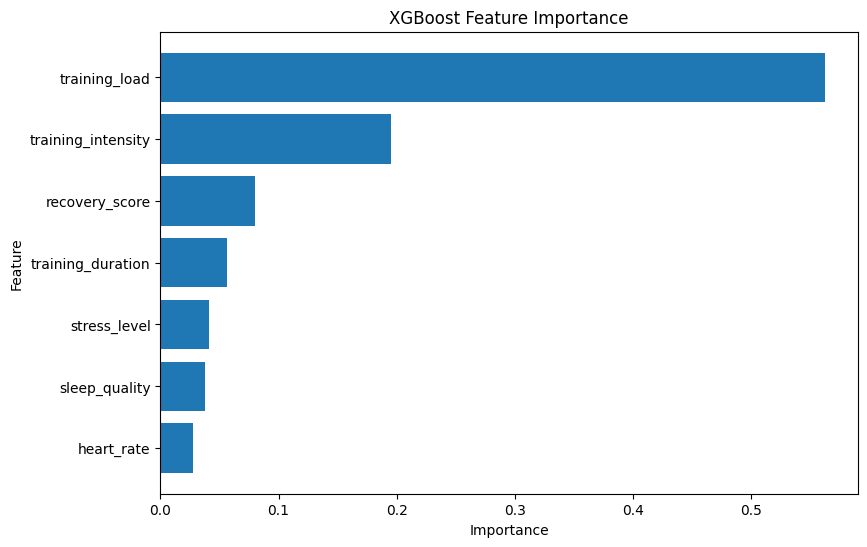

In [30]:
# ============================================
# CELL 29 - FEATURE IMPORTANCE GRAPH
# ============================================

plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [31]:
# ============================================
# CELL 30 - SAVE FEATURE IMPORTANCE
# ============================================

importance_df.to_csv(
    "/kaggle/working/xgboost_feature_importance.csv",
    index=False
)

print("Feature importance CSV saved!")

Feature importance CSV saved!


In [32]:
# ============================================
# CELL 31 - PERMUTATION IMPORTANCE
# ============================================

from sklearn.inspection import permutation_importance

print("Calculating permutation importance...")

perm_result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_Importance": perm_result.importances_mean,
    "Std_Importance": perm_result.importances_std
})

permutation_df = permutation_df.sort_values(
    "Mean_Importance",
    ascending=False
)

display(permutation_df)

Calculating permutation importance...


,Feature,Mean_Importance,Std_Importance
2,training_load,0.276086,0.010547
5,recovery_score,0.025434,0.004382
1,training_intensity,0.007486,0.002736
6,stress_level,0.007081,0.002632
0,training_duration,0.003081,0.001628
4,sleep_quality,-0.001154,0.002482
3,heart_rate,-0.002406,0.001314


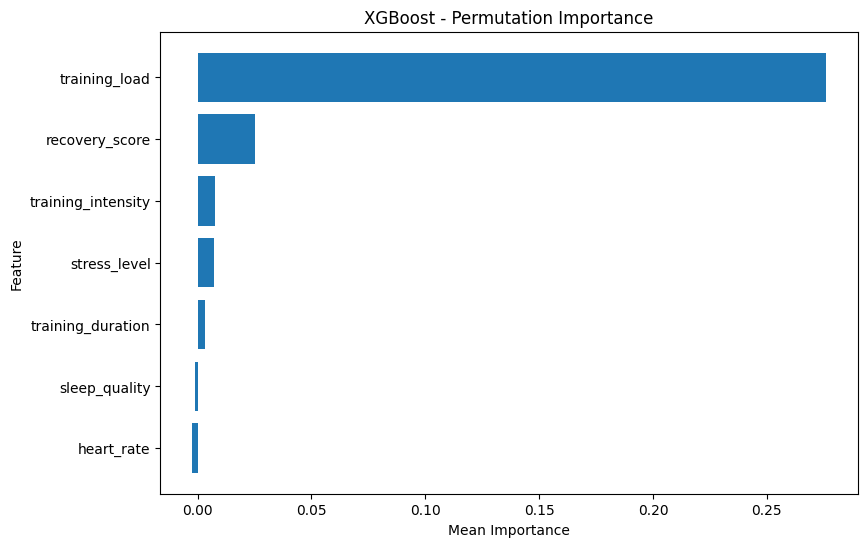

In [33]:
# ============================================
# CELL 32 - PERMUTATION IMPORTANCE GRAPH
# ============================================

plt.figure(figsize=(9, 6))

plt.barh(
    permutation_df["Feature"],
    permutation_df["Mean_Importance"]
)

plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.title("XGBoost - Permutation Importance")

plt.gca().invert_yaxis()

plt.show()

In [34]:
# ============================================
# CELL 33 - SAVE PERMUTATION IMPORTANCE
# ============================================

permutation_df.to_csv(
    "/kaggle/working/xgboost_permutation_importance.csv",
    index=False
)

print("Permutation importance CSV saved!")

Permutation importance CSV saved!


In [35]:
# ============================================
# CELL 34 - INSTALL SHAP
# ============================================

!pip install -q shap

In [36]:
# ============================================
# CELL 35 - SHAP EXPLAINER
# ============================================

import shap

print("Creating SHAP explainer...")

explainer = shap.TreeExplainer(
    xgb_model
)

# Explain up to 500 test samples
X_shap = X_test.iloc[:500].copy()

shap_result = explainer(
    X_shap
)

print("SHAP explanation generated!")

Creating SHAP explainer...
SHAP explanation generated!


In [37]:
# ============================================
# CELL 36 - SHAP GLOBAL EXPLANATION
# ============================================

shap_values = shap_result.values

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (500, 7, 3)


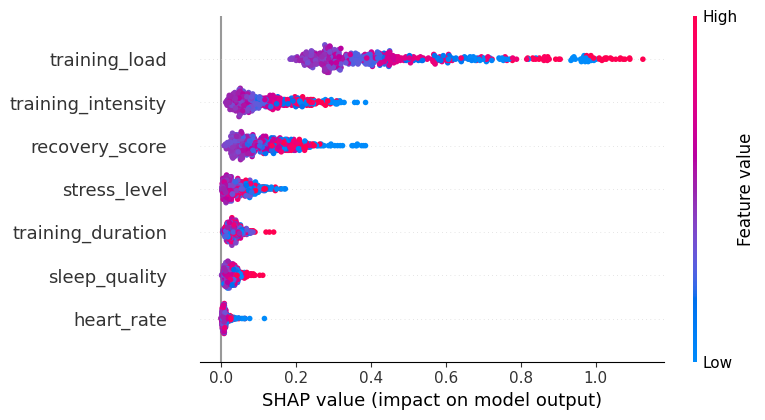

In [38]:
# ============================================
# SHAP SUMMARY
# ============================================

if shap_values.ndim == 3:

    shap_for_plot = np.mean(
        np.abs(shap_values),
        axis=2
    )

else:

    shap_for_plot = shap_values


shap.summary_plot(
    shap_for_plot,
    X_shap,
    feature_names=FEATURES
)

In [39]:
# ============================================
# CELL 37 - SHAP FEATURE IMPORTANCE
# ============================================

shap_importance = np.mean(
    np.abs(shap_for_plot),
    axis=0
)

shap_df = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_SHAP_Importance": shap_importance
})

shap_df = shap_df.sort_values(
    "Mean_SHAP_Importance",
    ascending=False
)

display(shap_df)

,Feature,Mean_SHAP_Importance
2,training_load,0.476626
1,training_intensity,0.124563
5,recovery_score,0.120684
6,stress_level,0.049310
0,training_duration,0.034417
4,sleep_quality,0.029037
3,heart_rate,0.012540


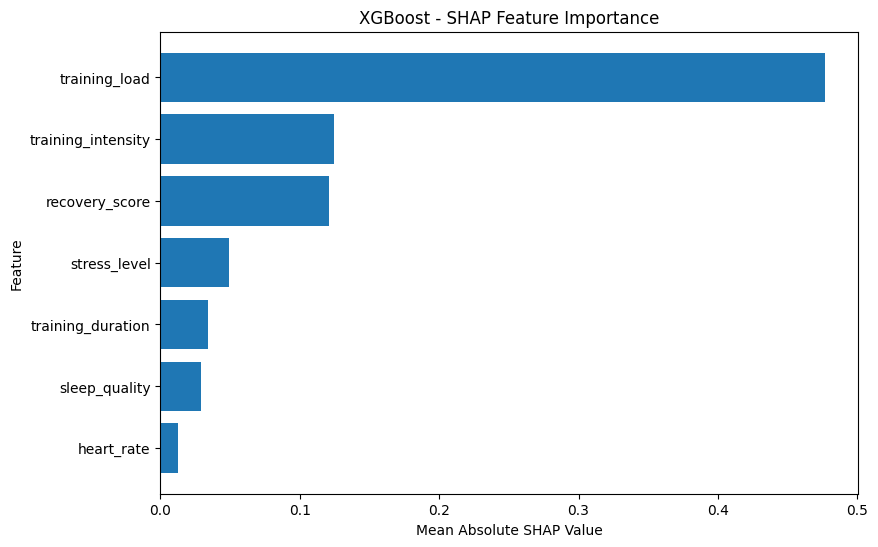

In [40]:
# ============================================
# CELL 38 - SHAP BAR PLOT
# ============================================

plt.figure(figsize=(9, 6))

plt.barh(
    shap_df["Feature"],
    shap_df["Mean_SHAP_Importance"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("XGBoost - SHAP Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [41]:
# ============================================
# CELL 39 - SAVE SHAP IMPORTANCE
# ============================================

shap_df.to_csv(
    "/kaggle/working/xgboost_shap_importance.csv",
    index=False
)

print("SHAP importance CSV saved!")

SHAP importance CSV saved!


In [42]:
# ============================================
# CELL 40 - INDIVIDUAL XAI
# ============================================

sample_index = 0

sample = X_test.iloc[
    [sample_index]
]

prediction = xgb_model.predict(
    sample
)[0]

probabilities = xgb_model.predict_proba(
    sample
)[0]

print("=" * 55)
print("       INDIVIDUAL XGBOOST EXPLANATION")
print("=" * 55)

print(
    "Actual class:",
    class_names[y_test.iloc[sample_index]]
)

print(
    "Predicted class:",
    class_names[prediction]
)

print("\nPrediction probabilities:")

for i, class_name in enumerate(class_names):

    print(
        f"{class_name}: "
        f"{probabilities[i] * 100:.2f}%"
    )

print("\nInput factors:")

for feature in FEATURES:

    print(
        f"{feature}: "
        f"{sample.iloc[0][feature]}"
    )

       INDIVIDUAL XGBOOST EXPLANATION
Actual class: Low
Predicted class: Moderate

Prediction probabilities:
Low: 35.98%
Moderate: 51.36%
High: 12.66%

Input factors:
training_duration: 64.63982198922983
training_intensity: 6.693077548723485
training_load: 545.8982747435949
heart_rate: 70.93557290430842
sleep_quality: 8.025855362910509
recovery_score: 76.84629528502566
stress_level: 0.3293105872099868


In [43]:
# ============================================
# CELL 41 - SHAP INDIVIDUAL EXPLANATION
# ============================================

individual_index = 0

# Get SHAP explanation for one test sample
individual_shap = shap_result[individual_index]

print("Individual SHAP explanation:")
print("Actual class:",
      class_names[y_test.iloc[individual_index]])

print("Predicted class:",
      class_names[y_pred[individual_index]])

# For multi-class XGBoost:
# SHAP shape = (features, classes)
print("SHAP explanation shape:",
      individual_shap.values.shape)

Individual SHAP explanation:
Actual class: Low
Predicted class: Moderate
SHAP explanation shape: (7, 3)


Showing SHAP explanation for: Moderate


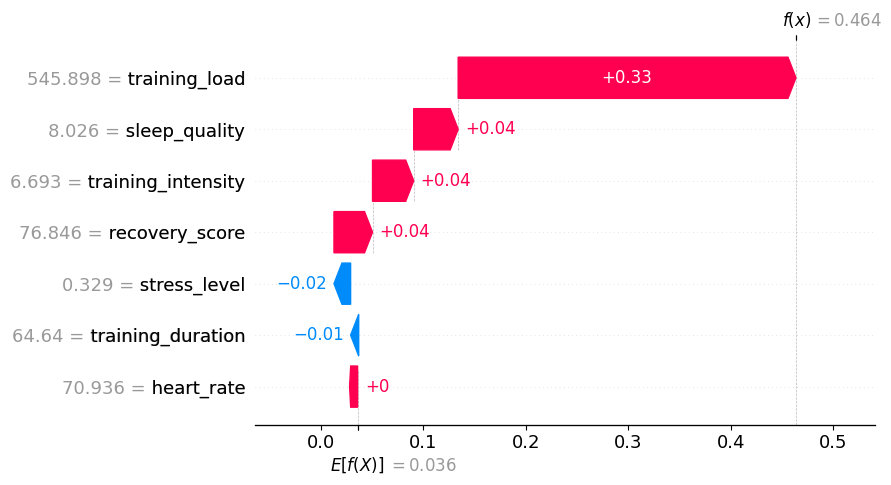

In [44]:
# ============================================
# WATERFALL FOR THE PREDICTED CLASS
# ============================================

predicted_class = y_pred[individual_index]

print(
    "Showing SHAP explanation for:",
    class_names[predicted_class]
)

shap.plots.waterfall(
    individual_shap[:, predicted_class],
    max_display=10
)

In [45]:
# ============================================
# CELL 42 - SAVE XGBOOST MODEL
# ============================================

MODEL_PATH = "/kaggle/working/xgboost_fatigue_model.json"

xgb_model.save_model(
    MODEL_PATH
)

print("XGBoost model saved successfully!")
print(MODEL_PATH)

XGBoost model saved successfully!
/kaggle/working/xgboost_fatigue_model.json


In [46]:
# ============================================
# CELL 43 - SAVE MODEL CONFIGURATION
# ============================================

model_config = {

    "model": "XGBoost",

    "features": FEATURES,

    "target": TARGET,

    "classes": {
        "0": "Low",
        "1": "Moderate",
        "2": "High"
    },

    "low_moderate_boundary": float(q1),

    "moderate_high_boundary": float(q2),

    "epochs": EPOCHS,

    "batch_size_display": BATCH_SIZE,

    "training_samples": len(X_train),

    "testing_samples": len(X_test)

}

with open(
    "/kaggle/working/xgboost_config.json",
    "w"
) as f:

    json.dump(
        model_config,
        f,
        indent=4
    )

print("Configuration saved!")

Configuration saved!


In [47]:
# ============================================
# CELL 44 - SHOW GENERATED FILES
# ============================================

print("=" * 60)
print("GENERATED FILES")
print("=" * 60)

for file in sorted(
    os.listdir("/kaggle/working")
):

    print(file)

GENERATED FILES
__notebook__.ipynb
xgboost_config.json
xgboost_evaluation_metrics.csv
xgboost_fatigue_model.json
xgboost_feature_importance.csv
xgboost_permutation_importance.csv
xgboost_shap_importance.csv
xgboost_training_history.csv
xgboost_wall_time.csv
